In [362]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso






In [363]:
train = pd.read_csv("./home-data-for-ml-course/train.csv")

test = pd.read_csv("./home-data-for-ml-course/test.csv")
submission = pd.read_csv("./home-data-for-ml-course/sample_submission.csv")
train = train.drop("Id", axis=1)
test = test.drop("Id", axis=1)
train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [364]:
train["LotFrontage"].nunique()

110

In [359]:
test.select_dtypes(include=['int64', 'float64']).isna().sum().loc[lambda x : x > 0]

LotFrontage     227
MasVnrArea       15
BsmtFinSF1        1
BsmtFinSF2        1
BsmtUnfSF         1
TotalBsmtSF       1
BsmtFullBath      2
BsmtHalfBath      2
GarageYrBlt      78
GarageCars        1
GarageArea        1
dtype: int64

In [71]:
train["MasVnrType"].value_counts()

MasVnrType
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [72]:
train["Alley"].value_counts()

Alley
Grvl    50
Pave    41
Name: count, dtype: int64

In [213]:
corr = train.select_dtypes(include=['int64', 'float64']).corr()
results = []
for i in range(corr.shape[0]):
    i = corr.index[i]
    for j in range(corr.shape[1]):
        j = corr.index[j]
        if corr[i][j] >= 0.6 and i != j and (f"{i} and {j}" not in results):
            print("corrélation entre :", i, "et", j, "est", corr[i][j])
            results.append(f"{i} and {j}")
            results.append(f"{j} and {i}")



corrélation entre : OverallQual et GarageCars est 0.6006707165907149
corrélation entre : OverallQual et SalePrice est 0.7909816005838053
corrélation entre : YearBuilt et GarageYrBlt est 0.8256674841743408
corrélation entre : YearRemodAdd et GarageYrBlt est 0.6422767797035356
corrélation entre : BsmtFinSF1 et BsmtFullBath est 0.6492117535742649
corrélation entre : TotalBsmtSF et 1stFlrSF est 0.8195299750050339
corrélation entre : TotalBsmtSF et SalePrice est 0.6135805515591943
corrélation entre : 1stFlrSF et SalePrice est 0.6058521846919153
corrélation entre : 2ndFlrSF et GrLivArea est 0.6875010641666033
corrélation entre : 2ndFlrSF et HalfBath est 0.6097073002717436
corrélation entre : 2ndFlrSF et TotRmsAbvGrd est 0.6164226354915431
corrélation entre : GrLivArea et FullBath est 0.6300116462511148
corrélation entre : GrLivArea et TotRmsAbvGrd est 0.8254893743088425
corrélation entre : GrLivArea et SalePrice est 0.7086244776126515
corrélation entre : BedroomAbvGr et TotRmsAbvGrd est 0.67

In [365]:
corr = train.select_dtypes(include=['int64', 'float64']).corr()
results = []
for i in range(corr.shape[0]):
    i = corr.index[i]
    for j in range(corr.shape[1]):
        j = corr.index[j]
        if i != j and (f"{i} and {j}" not in results) and (i == "LotArea" or j == "LotArea"):
            print("corrélation entre :", i, "et", j, "est", corr[i][j])
            results.append(f"{i} and {j}")
            results.append(f"{j} and {i}")

corrélation entre : MSSubClass et LotArea est -0.13978108172014597
corrélation entre : LotFrontage et LotArea est 0.4260950187718081
corrélation entre : LotArea et OverallQual est 0.10580574175496422
corrélation entre : LotArea et OverallCond est -0.005636270274099278
corrélation entre : LotArea et YearBuilt est 0.014227651757025093
corrélation entre : LotArea et YearRemodAdd est 0.013788427078155424
corrélation entre : LotArea et MasVnrArea est 0.10415982154021264
corrélation entre : LotArea et BsmtFinSF1 est 0.21410313070557713
corrélation entre : LotArea et BsmtFinSF2 est 0.11116974549624871
corrélation entre : LotArea et BsmtUnfSF est -0.00261835995009543
corrélation entre : LotArea et TotalBsmtSF est 0.2608331345451572
corrélation entre : LotArea et 1stFlrSF est 0.29947457850776266
corrélation entre : LotArea et 2ndFlrSF est 0.05098594829349377
corrélation entre : LotArea et LowQualFinSF est 0.004778969866349555
corrélation entre : LotArea et GrLivArea est 0.26311616716714803
corr

In [361]:
corr = train.select_dtypes(include=['int64', 'float64']).corr()
for i in range(corr.shape[0]):
    i = corr.index[i]
    for j in range(corr.shape[1]):
        j = corr.index[j]
        if corr[i][j] <= 0.1 and corr[i][j] >= -0.1 and (i == "SalePrice"):
            train = train.drop(j, axis=1)
            test = test.drop(j, axis=1)
            print(j, "dropped")
            

MSSubClass dropped
OverallCond dropped
BsmtFinSF2 dropped
LowQualFinSF dropped
BsmtHalfBath dropped
3SsnPorch dropped
PoolArea dropped
MiscVal dropped
MoSold dropped
YrSold dropped


We can drop GarageYrBlt as it is logically correlated with YearBuilt, both are generally probably built the same year and so they dont carry much different informations.
we can apply the same logic to the other greatly correlated values.

In [366]:
train = train.drop(["GarageYrBlt", "TotalBsmtSF", "GarageCars", "TotRmsAbvGrd"], axis=1)
test = test.drop(["GarageYrBlt", "TotalBsmtSF", "GarageCars", "TotRmsAbvGrd"], axis=1)

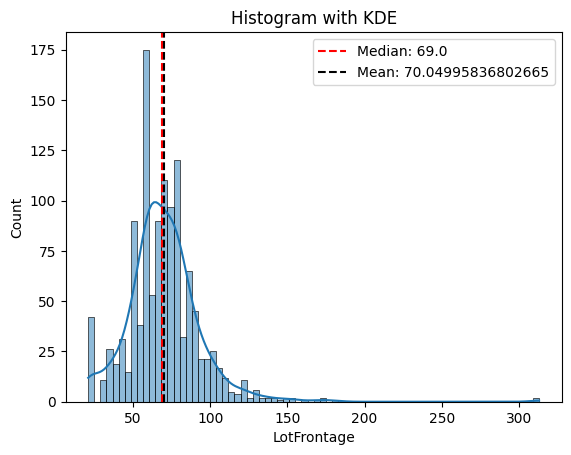

In [313]:
median_val = train["LotFrontage"].median()
mean_val = train["LotFrontage"].mean()

sns.histplot(train["LotFrontage"], kde=True)
plt.axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val}')
plt.axvline(mean_val, color='black', linestyle='--', label=f'Mean: {mean_val}')
plt.legend()
plt.title("Histogram with KDE")
plt.show()

In [128]:
train.select_dtypes(include=['int64', 'float64']).isna().sum().loc[lambda x: x > 0]
train["LotFrontage"] = train["LotFrontage"].fillna(train["LotFrontage"].median)
test["LotFrontage"] = test["LotFrontage"].fillna(test["LotFrontage"].median)

In [209]:
train.select_dtypes(include=['int64', 'float64', 'number']).isna().sum().loc[lambda x: x > 0]


LotFrontage    259
MasVnrArea       8
dtype: int64

In [210]:
test.select_dtypes(include=['int64', 'float64', 'number']).isna().sum().loc[lambda x: x > 0]


LotFrontage     227
MasVnrArea       15
BsmtFinSF1        1
BsmtUnfSF         1
BsmtFullBath      2
GarageArea        1
dtype: int64

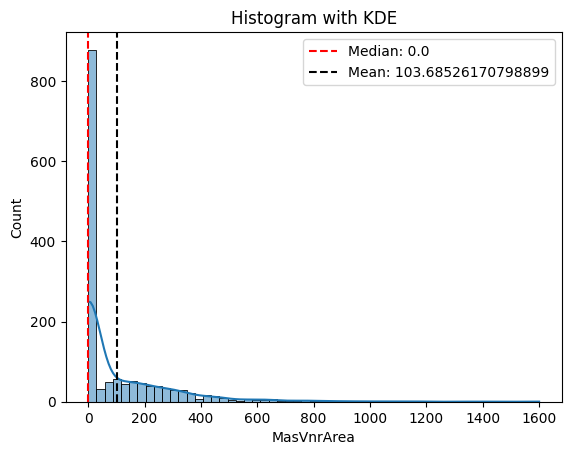

In [159]:
median_val = train["MasVnrArea"].median()
mean_val = train["MasVnrArea"].mean()

sns.histplot(train["MasVnrArea"], kde=True)
plt.axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val}')
plt.axvline(mean_val, color='black', linestyle='--', label=f'Mean: {mean_val}')
plt.legend()
plt.title("Histogram with KDE")
plt.show()

In [22]:
train["MasVnrArea"] = train["MasVnrArea"].fillna(0)
test["MasVnrArea"] = test["MasVnrArea"].fillna(0)


In [23]:
train.select_dtypes(include=['int64', 'float64']).mean().loc[lambda x: x < 10]

OverallQual     6.099315
OverallCond     5.575342
LowQualFinSF    5.844521
BsmtFullBath    0.425342
BsmtHalfBath    0.057534
FullBath        1.565068
HalfBath        0.382877
BedroomAbvGr    2.866438
KitchenAbvGr    1.046575
Fireplaces      0.613014
3SsnPorch       3.409589
PoolArea        2.758904
MoSold          6.321918
dtype: float64

In [24]:
train.isna().sum().loc[lambda x: x > 0]

Alley           1369
MasVnrType       872
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [25]:
test.fillna(test.mean(numeric_only=True), inplace=True)
test.select_dtypes(include=['int64', 'float64']).isna().sum().loc[lambda x: x > 0]


Series([], dtype: int64)

In [104]:
test.isna().sum().loc[lambda x: x > 0]

LotFrontage     227
MasVnrArea       15
BsmtFinSF1        1
BsmtFinSF2        1
BsmtUnfSF         1
BsmtFullBath      2
BsmtHalfBath      2
GarageArea        1
dtype: int64

In [367]:
non_num_cols = test.select_dtypes(exclude=['int64', 'float64']).columns
test[non_num_cols] = test[non_num_cols].fillna("None")

In [368]:
non_num_cols = train.select_dtypes(exclude=['number']).columns
train[non_num_cols] = train[non_num_cols].fillna("None")

In [369]:
train.isna().sum().loc[lambda x: x > 0]

LotFrontage    259
MasVnrArea       8
dtype: int64

In [370]:
train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,...,0,None,None,None,0,12,2008,WD,Normal,250000


In [371]:
train.select_dtypes(include=['int64', 'float64'])

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,0,40,0,0,0,0,0,8,2007,175000
1456,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,349,0,0,0,0,0,0,2,2010,210000
1457,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,0,60,0,0,0,0,2500,5,2010,266500
1458,20,68.0,9717,5,6,1950,1996,0.0,49,1029,...,366,0,112,0,0,0,0,4,2010,142125


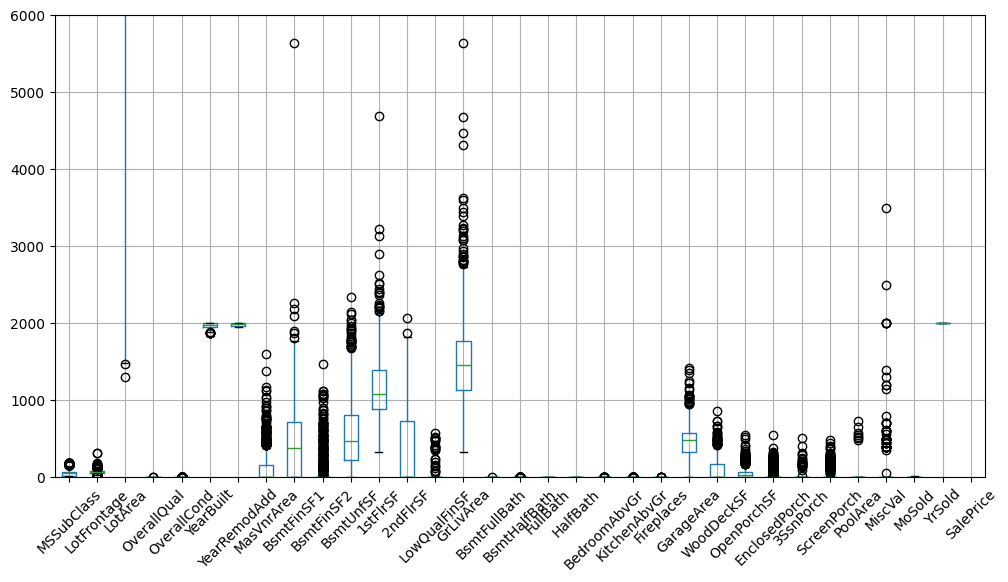

In [372]:
import matplotlib.pyplot as plt

train.select_dtypes(include=['int64', 'float64']).boxplot(figsize=(12,6))
plt.ylim(0, 6000)
plt.xticks(rotation=45)
plt.show()

In [373]:
columns = train.select_dtypes(include=['int64', 'float64']).columns
for i in columns:
    col = train[i]
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = col.loc[lambda x: (x < lower) | (x > upper)]

    print("Number of outliers in", i, "is :", outliers.shape[0])

Number of outliers in MSSubClass is : 103
Number of outliers in LotFrontage is : 88
Number of outliers in LotArea is : 69
Number of outliers in OverallQual is : 2
Number of outliers in OverallCond is : 125
Number of outliers in YearBuilt is : 7
Number of outliers in YearRemodAdd is : 0
Number of outliers in MasVnrArea is : 96
Number of outliers in BsmtFinSF1 is : 7
Number of outliers in BsmtFinSF2 is : 167
Number of outliers in BsmtUnfSF is : 29
Number of outliers in 1stFlrSF is : 20
Number of outliers in 2ndFlrSF is : 2
Number of outliers in LowQualFinSF is : 26
Number of outliers in GrLivArea is : 31
Number of outliers in BsmtFullBath is : 1
Number of outliers in BsmtHalfBath is : 82
Number of outliers in FullBath is : 0
Number of outliers in HalfBath is : 0
Number of outliers in BedroomAbvGr is : 35
Number of outliers in KitchenAbvGr is : 68
Number of outliers in Fireplaces is : 5
Number of outliers in GarageArea is : 21
Number of outliers in WoodDeckSF is : 32
Number of outliers in

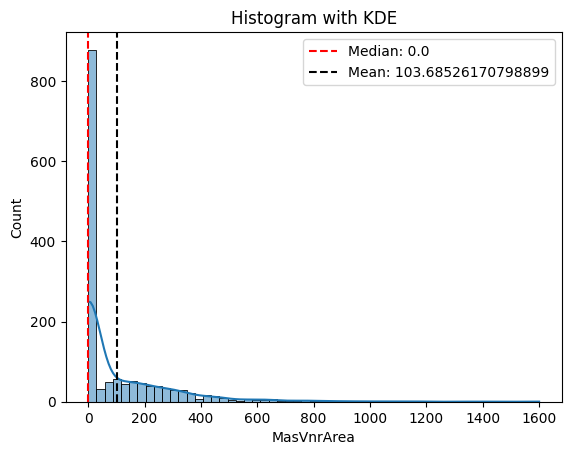

In [374]:
median_val = train["MasVnrArea"].median()
mean_val = train["MasVnrArea"].mean()

sns.histplot(train["MasVnrArea"], kde=True)
plt.axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val}')
plt.axvline(mean_val, color='black', linestyle='--', label=f'Mean: {mean_val}')
plt.legend()
plt.title("Histogram with KDE")
plt.show()

In [339]:
train["MasVnrArea"].loc[lambda x: x > 0].shape

(591,)

In [340]:
train["MasVnrArea_positive"] = train["MasVnrArea"] > 0
train["MasVnrArea_positive"]

0        True
1       False
2        True
3       False
4        True
        ...  
1455    False
1456     True
1457    False
1458    False
1459    False
Name: MasVnrArea_positive, Length: 1460, dtype: bool

In [295]:
Q1 = train["MasVnrArea"].quantile(0.25)
Q3 = train["MasVnrArea"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

Q95 = train["MasVnrArea"].quantile(0.95)
Q05 = train["MasVnrArea"].quantile(0.05)

train["MasVnrArea"] = train["MasVnrArea"].where((train["MasVnrArea"] >= lower), Q05)
train["MasVnrArea"] = train["MasVnrArea"].where((train["MasVnrArea"] <= upper), Q95)

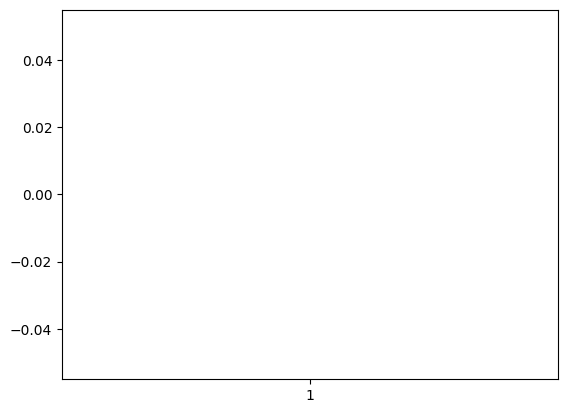

In [341]:
plt.boxplot(train['MasVnrArea'])
plt.show()

In [324]:
Q1 = train["LotFrontage"].quantile(0.25)
Q3 = train["LotFrontage"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

Q95 = train["LotFrontage"].quantile(0.95)
Q05 = train["LotFrontage"].quantile(0.05)

train["LotFrontage"] = train["LotFrontage"].where((train["LotFrontage"] >= lower), Q05)
train["LotFrontage"] = train["LotFrontage"].where((train["LotFrontage"] <= upper), Q95)

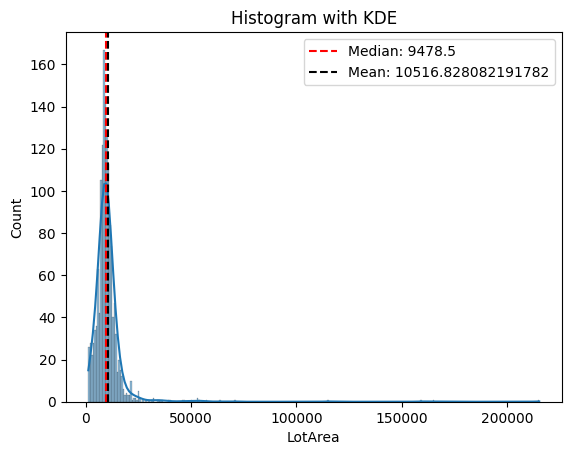

In [375]:
median_val = train["LotArea"].median()
mean_val = train["LotArea"].mean()

sns.histplot(train["LotArea"], kde=True)
plt.axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val}')
plt.axvline(mean_val, color='black', linestyle='--', label=f'Mean: {mean_val}')
plt.legend()
plt.title("Histogram with KDE")
plt.show()

In [376]:
Q1 = train["LotArea"].quantile(0.25)
Q3 = train["LotArea"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

Q95 = train["LotArea"].quantile(0.95)
Q05 = train["LotArea"].quantile(0.05)

train["LotArea"] = train["LotArea"].where((train["LotArea"] >= lower), Q05)
train["LotArea"] = train["LotArea"].where((train["LotArea"] <= upper), Q95)

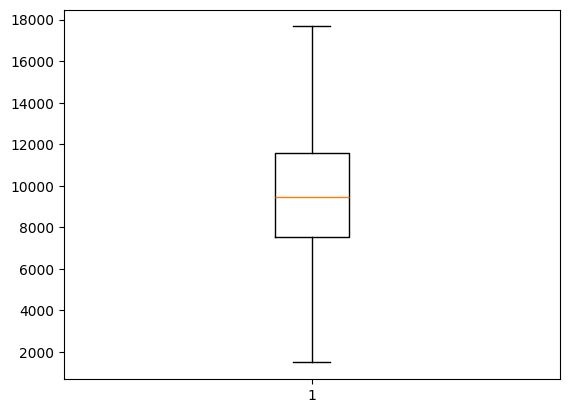

In [377]:
plt.boxplot(train['LotArea'])
plt.show()

In [378]:
test.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,20,RH,80.0,11622,Pave,None,Reg,Lvl,AllPub,Inside,...,120,0,None,MnPrv,None,0,6,2010,WD,Normal
1,20,RL,81.0,14267,Pave,None,IR1,Lvl,AllPub,Corner,...,0,0,None,None,Gar2,12500,6,2010,WD,Normal
2,60,RL,74.0,13830,Pave,None,IR1,Lvl,AllPub,Inside,...,0,0,None,MnPrv,None,0,3,2010,WD,Normal
3,60,RL,78.0,9978,Pave,None,IR1,Lvl,AllPub,Inside,...,0,0,None,None,None,0,6,2010,WD,Normal
4,120,RL,43.0,5005,Pave,None,IR1,HLS,AllPub,Inside,...,144,0,None,None,None,0,1,2010,WD,Normal


In [346]:
train.select_dtypes(include=['int64', 'float64']).var().loc[lambda x: x < 10]


OverallQual     1.912679
OverallCond     1.238322
BsmtFullBath    0.269268
BsmtHalfBath    0.057003
FullBath        0.303508
HalfBath        0.252894
BedroomAbvGr    0.665494
KitchenAbvGr    0.048549
Fireplaces      0.415595
MoSold          7.309595
YrSold          1.763837
dtype: float64

In [164]:
numerical_train = train.select_dtypes(include=['int64', 'float64']).drop("SalePrice", axis=1)
scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(numerical_train)



In [387]:
y = train["SalePrice"]
X_train = train.drop(columns=["SalePrice"])

In [388]:
X = pd.get_dummies(X_train, drop_first=True)
X.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450.0,7,5,2003,2003,196.0,706,0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600.0,6,8,1976,1976,0.0,978,0,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250.0,7,5,2001,2002,162.0,486,0,...,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550.0,7,5,1915,1970,0.0,216,0,...,False,False,False,False,True,False,False,False,False,False
4,60,84.0,14260.0,8,5,2000,2000,350.0,655,0,...,False,False,False,False,True,False,False,False,True,False


In [389]:
X_test = pd.get_dummies(test, drop_first=True)
X_test = X_test.reindex(columns=X.columns, fill_value=0)

In [390]:
X_test

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,20,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,...,False,False,False,False,True,False,False,False,True,False
1,20,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,...,False,False,False,False,True,False,False,False,True,False
2,60,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,...,False,False,False,False,True,False,False,False,True,False
3,60,78.0,9978,6,6,1998,1998,20.0,602.0,0.0,...,False,False,False,False,True,False,False,False,True,False
4,120,43.0,5005,8,5,1992,1992,0.0,263.0,0.0,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,160,21.0,1936,4,7,1970,1970,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
1455,160,21.0,1894,4,5,1970,1970,0.0,252.0,0.0,...,False,False,False,False,True,False,False,False,False,False
1456,20,160.0,20000,5,7,1960,1996,0.0,1224.0,0.0,...,False,False,False,False,True,False,False,False,False,False
1457,85,62.0,10441,5,5,1992,1992,0.0,337.0,0.0,...,False,False,False,False,True,False,False,False,True,False


In [167]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test = pd.get_dummies(test, drop_first=True)
X_test = X_test.reindex(columns=X.columns, fill_value=0)
X_test_scaled = scaler.fit_transform(X_test)

In [130]:

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.4, random_state=42)

In [131]:
X_scaled

array([[-0.20714171,  0.65147924,  1.05099379, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [-0.09188637, -0.07183611,  0.15673371, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [ 0.07347998,  0.65147924,  0.9847523 , ..., -0.11785113,
         0.4676514 , -0.30599503],
       ...,
       [-0.14781027,  0.65147924, -1.00249232, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [-0.08016039, -0.79515147, -0.70440562, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [-0.05811155, -0.79515147, -0.20759447, ..., -0.11785113,
         0.4676514 , -0.30599503]], shape=(1460, 355))

In [132]:
lasso = Lasso()
lasso.fit(X_scaled, y)

c:\Users\ROG STRIX G17\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.171e+11, tolerance: 9.208e+08
  model = cd_fast.enet_coordinate_descent(


,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [133]:
y_pred = lasso.predict(X_test_scaled)

In [134]:
y_pred

array([109935.79861717, 162204.68544403, 179193.39360791, ...,
       400207.05898437,  98649.60767397, 206647.57821822], shape=(1459,))

In [135]:
y_test

892     154500
1105    325000
413     115000
522     159000
1036    315500
         ...  
1330    227000
1103    159500
752     217000
1353    410000
376     148000
Name: SalePrice, Length: 584, dtype: int64

In [136]:
param_grid = {
    'alpha' : [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]
}


In [137]:
from sklearn.model_selection import GridSearchCV
lasso_cv = GridSearchCV(lasso, param_grid, cv=3, n_jobs=-1)
lasso_cv.fit(X_scaled, y)

,estimator,Lasso()
,param_grid,"{'alpha': [0.0001, 0.001, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1000


In [138]:
y_pred2 = lasso_cv.predict(X_test_scaled)

In [139]:
y_pred2

array([114537.83755259, 161804.03504198, 177669.65509977, ...,
       338598.24909359, 117973.64762116, 221542.70516396], shape=(1459,))

In [42]:
coeffs = lasso_cv.best_estimator_.coef_
coeffs

array([ 2.44261415e+03,  1.78598623e+04,  5.19397608e+03,  4.86629644e+03,
        3.05136927e+03,  4.98906010e+03,  0.00000000e+00,  3.86846013e+03,
        0.00000000e+00,  2.33315917e+04,  1.82581573e+03,  7.21920857e+02,
        3.44316024e+01, -0.00000000e+00, -3.07852549e+03,  2.09831085e+03,
        5.70340510e+03,  1.83160027e+03,  4.95906934e+02, -0.00000000e+00,
        1.29460489e+03,  0.00000000e+00, -0.00000000e+00,  8.14708070e+02,
       -7.26655940e+02, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
        0.00000000e+00, -0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
       -0.00000000e+00, -0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
       -2.24446195e+02,  1.19089589e+03, -0.00000000e+00,  4.16628441e+02,
        0.00000000e+00,  0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        1.14693067e+03, -

In [206]:
test = pd.read_csv("./home-data-for-ml-course/test.csv")
submission = {"Id": test["Id"], "SalePrice": y_pred2}
submission = pd.DataFrame(data=submission)
submission.to_csv("submissions.csv", index=False)

In [391]:
import re
X.columns = [re.sub(r'[\[\]<]', '_', col) for col in X.columns]
X_test.columns = [re.sub(r'[\[\]<]', '_', col) for col in X_test.columns]

In [392]:
import xgboost as xgb

params = {
    'learning_rate': 0.1,
    'max_depth': 5,
    'subsample': 0.8,
    'reg_lambda': 1.5,
    'gamma': 0.0,
    'min_child_weight': 25,
    'base_score': 0.0,
    'tree_method': 'exact',
    'colsample_bytree': 0.8
}

dtrain = xgb.DMatrix(X, label=y)
X_test = xgb.DMatrix(X_test)


In [393]:
model_xgb = xgb.train(params, dtrain, 500)


In [394]:
pred_xgb = model_xgb.predict(X_test)

In [395]:
test = pd.read_csv("./home-data-for-ml-course/test.csv")
submission = {"Id": test["Id"], "SalePrice": pred_xgb}
submission = pd.DataFrame(data=submission)
submission.to_csv("submissions36.csv", index=False)

In [145]:
xgb_cv = GridSearchCV(model_xgb, params, cv=3, n_jobs=-1)